In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split


In [63]:
import nltk
nltk.download("twitter_samples")

from nltk.corpus import twitter_samples
import pandas as pd

# Load tweets
pos = twitter_samples.strings("positive_tweets.json")
neg = twitter_samples.strings("negative_tweets.json")

# Create DataFrame
df = pd.DataFrame({
    "text": pos + neg,
    "label": [1] * len(pos) + [0] * len(neg)
})

print(df.head())
print(df.shape)

[nltk_data] Downloading package twitter_samples to
[nltk_data]     C:\Users\khare\AppData\Roaming\nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


                                                text  label
0  #FollowFriday @France_Inte @PKuchly57 @Milipol...      1
1  @Lamb2ja Hey James! How odd :/ Please call our...      1
2  @DespiteOfficial we had a listen last night :)...      1
3                               @97sides CONGRATS :)      1
4  yeaaaah yippppy!!!  my accnt verified rqst has...      1
(10000, 2)


In [64]:
print(df.head())

print("\nClass Distribution:")
print(df["label"].value_counts())

                                                text  label
0  #FollowFriday @France_Inte @PKuchly57 @Milipol...      1
1  @Lamb2ja Hey James! How odd :/ Please call our...      1
2  @DespiteOfficial we had a listen last night :)...      1
3                               @97sides CONGRATS :)      1
4  yeaaaah yippppy!!!  my accnt verified rqst has...      1

Class Distribution:
label
1    5000
0    5000
Name: count, dtype: int64


In [65]:
import re

def clean(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"] = df["text"].apply(clean)

In [78]:
from collections import Counter

counter = Counter()

for text in df["text"]:
    counter.update(text.split())

vocab = {"<PAD>": 0, "<UNK>": 1}

for word, freq in counter.items():
    if freq >= 2:
        vocab[word] = len(vocab)

print("Vocabulary Size:", len(vocab))

MAX_LEN = 100

def encode(sentence):
    ids = [vocab.get(word, 1) for word in sentence.split()]

    if len(ids) > MAX_LEN:
        ids = ids[:MAX_LEN]
    else:
        ids += [0] * (MAX_LEN - len(ids))

    return ids

df["encoded"] = df["text"].apply(encode)

Vocabulary Size: 4476


In [83]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,      
    random_state=42,
    stratify=df["label"]  
)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

Training samples: 8000
Testing samples: 2000


In [84]:
class NewsDataset(Dataset):

    def __init__(self, dataframe):
        self.X = dataframe["encoded"].tolist()
        self.y = dataframe["label"].tolist()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx]),
            torch.tensor(self.y[idx])
        )

train_loader = DataLoader(
    NewsDataset(train_df),
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    NewsDataset(test_df),
    batch_size=128,
    shuffle=False
)

In [85]:
class TweetLSTM(nn.Module):

    def __init__(self):
        super().__init__()

        self.embedding = nn.Embedding(len(vocab), 200, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=200,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
        )
        self.fc = nn.Linear(256, 2)

    def forward(self, x):

        x = self.embedding(x)

        output, (hidden, cell) = self.lstm(x)

        hidden = self.dropout(hidden[-1])

        return self.fc(hidden)

In [86]:
losses = []

EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for X, y in train_loader:

        optimizer.zero_grad()

        outputs = model(X)

        loss = criterion(outputs, y)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    losses.append(epoch_loss)

    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}")


Epoch 1: Loss=0.8680
Epoch 2: Loss=0.3511
Epoch 3: Loss=0.1977
Epoch 4: Loss=0.1142
Epoch 5: Loss=0.1034


In [ ]:

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for X, y in test_loader:

        outputs = model(X)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

accuracy = np.mean(np.array(all_preds) == np.arr ay(all_labels)) * 100

print(f"\nTest Accuracy: {accuracy:.2f}%")

# Classification Report
print("\nClassification Report")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["Negative", "Positive"]
))


Test Accuracy: 60.30%

Classification Report
              precision    recall  f1-score   support

    Negative       0.60      0.60      0.60      1000
    Positive       0.60      0.60      0.60      1000

    accuracy                           0.60      2000
   macro avg       0.60      0.60      0.60      2000
weighted avg       0.60      0.60      0.60      2000



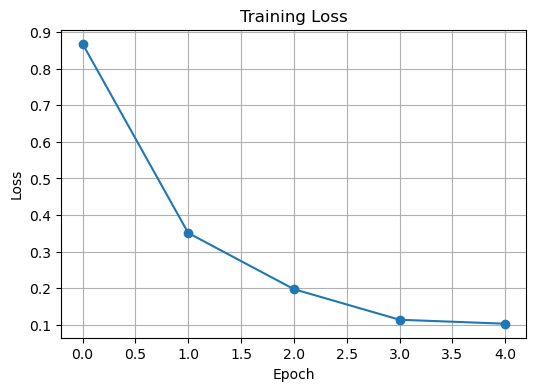

In [89]:
plt.figure(figsize=(6,4))
plt.plot(losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

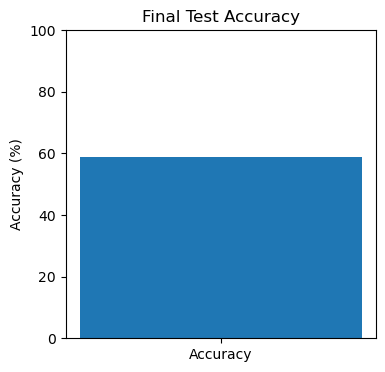

In [ ]:
plt.figure(figsize=(4,4))
plt.bar(["Accuracy"], [accuracy])
plt.ylim(0,100)
plt.ylabel("Accuracy (%)")
plt.title("Final Test Accuracy")
plt.show()

<Figure size 700x700 with 0 Axes>

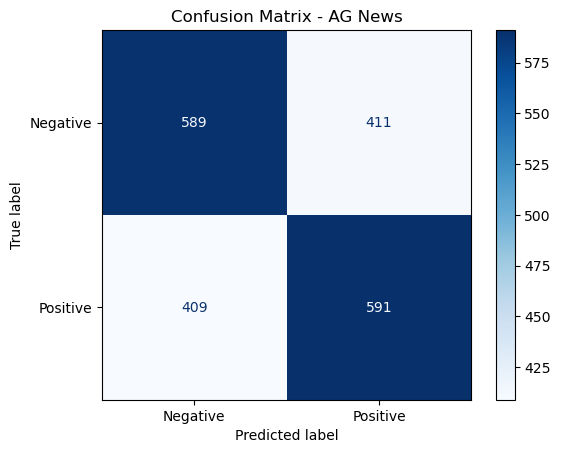

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

plt.figure(figsize=(7,7))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - AG News")
plt.show()